In [6]:
import numpy as np
import matplotlib.pyplot as plt
import time

np.random.seed(1234)

%matplotlib inline
%config InlineBackend.figure_format = 'retina'
plt.rcParams["figure.figsize"] = [16, 9]

### Handy utility functions

In [7]:
def append_ones(matrix: np.ndarray, axis: int = 1) -> np.ndarray:
    """
    Appends a column of ones to the right side of a 2D matrix.
    """
    return np.concatenate(
        (matrix, np.ones((matrix.shape[0], 1), dtype=np.float32)), axis=axis
    )


def zeros(*dims: int) -> np.ndarray:
    """
    Creates a NumPy array of zeros with the given shape.

    Args:
        *dims:  Variable number of integers defining the shape of the array.
                E.g. zeros(3, 4) creates a (3, 4) array.
    """
    return np.zeros(shape=tuple(dims), dtype=np.float32)


def ones(*dims: int) -> np.ndarray:
    """
    Creates a NumPy array of ones with the given shape.

    Args:
        *dims:  Variable number of integers defining the shape of the array.
                E.g. ones(3, 4) creates a (3, 4) array.
    """
    return np.ones(shape=tuple(dims), dtype=np.float32)


def rand(*dims: int) -> np.ndarray:
    """
    Creates a NumPy array of random values sampled from a uniform [0, 1) distribution.

    Args:
        *dims:  Variable number of integers defining the shape of the array.
                E.g. rand(3, 4) creates a (3, 4) array.
    """
    return np.random.rand(*dims).astype(np.float32)


def randn(*dims: int) -> np.ndarray:
    """
    Creates a NumPy array of random values sampled from a standard normal distribution.

    Args:
        *dims:  Variable number of integers defining the shape of the array.
                E.g. rand(3, 4) creates a (3, 4) array.
    """
    return np.random.randn(*dims).astype(np.float32)


def chunks(seq: list, size: int) -> tuple[np.ndarray]:
    """
    Splits a sequence into consecutive chunks of a given size.

    The last chunk may be smaller than `size` if the sequence length
    is not evenly divisible.

    Args:
        seq:  The input sequence (e.g. list or other sliceable) to split.
        size: The maximum number of elements in each chunk.

    Returns:
        Successive sub-sequences of length `size` (or less for the final chunk).
    """
    return tuple([seq[pos : (pos + size)] for pos in range(0, len(seq), size)])


def as_matrix(vector: np.ndarray) -> np.ndarray:
    """Reshape 1D vector to column matrix."""
    return np.reshape(vector, (-1, 1))


def arrange_tiles_img(examples: np.ndarray) -> np.ndarray:
    """
    Arrange 2D matrices as tiles

    Takes 4D `examples` tensor with dims:
        rows x cols x tile_height x tile_width
    """
    rows_count = examples.shape[0]
    cols_count = examples.shape[1]
    tile_height = examples.shape[2]
    tile_width = examples.shape[3]

    space_between_tiles = 2
    img_matrix = np.empty(
        shape=(
            rows_count * (tile_height + space_between_tiles) - space_between_tiles,
            cols_count * (tile_width + space_between_tiles) - space_between_tiles,
        )
    )
    img_matrix.fill(np.nan)

    for r in range(rows_count):
        for c in range(cols_count):
            x_0 = r * (tile_height + space_between_tiles)
            y_0 = c * (tile_width + space_between_tiles)
            img_matrix[x_0 : x_0 + tile_height, y_0 : y_0 + tile_width] = examples[r, c]

    return img_matrix


def tiles(examples: np.ndarray) -> None:
    """Previews the arrange tiles"""
    img = arrange_tiles_img(examples)
    plt.matshow(img, cmap="gray", interpolation="none")
    plt.axis("off")
    plt.show()


def draw_rbm_filters(rbm: "RestrictedBoltzmannMachine") -> None:
    filters = np.reshape(np.transpose(rbm.W)[:-1, :-1], newshape=(8, -1, 28, 28))
    tiles(filters)


def draw_layer_filters(layer: "Layer") -> None:
    filters = np.reshape(layer.W[:-1].T, newshape=(8, -1, 28, 28))
    tiles(filters)

### Activation functions

In [8]:
def sigmoid(batch, stochastic=False):
    activations = 1.0 / (1.0 + np.exp(-batch))
    if stochastic:
        return activations > rand(*activations.shape).astype(np.float32)
    else:
        return activations


def sigmoid_derivative(batch):
    s = sigmoid(batch)
    return s * (1.0 - s)


# Tip: its a plain linear function with optional stochastic noise
def gaussian(batch: np.ndarray, stochastic: bool = False) -> np.ndarray:
    if stochastic:
        noise = randn(*batch.shape)
        return batch + noise
    return batch


def gaussian_derivative(batch: np.ndarray) -> np.ndarray:
    return ones(*batch.shape)

# MNIST dataset

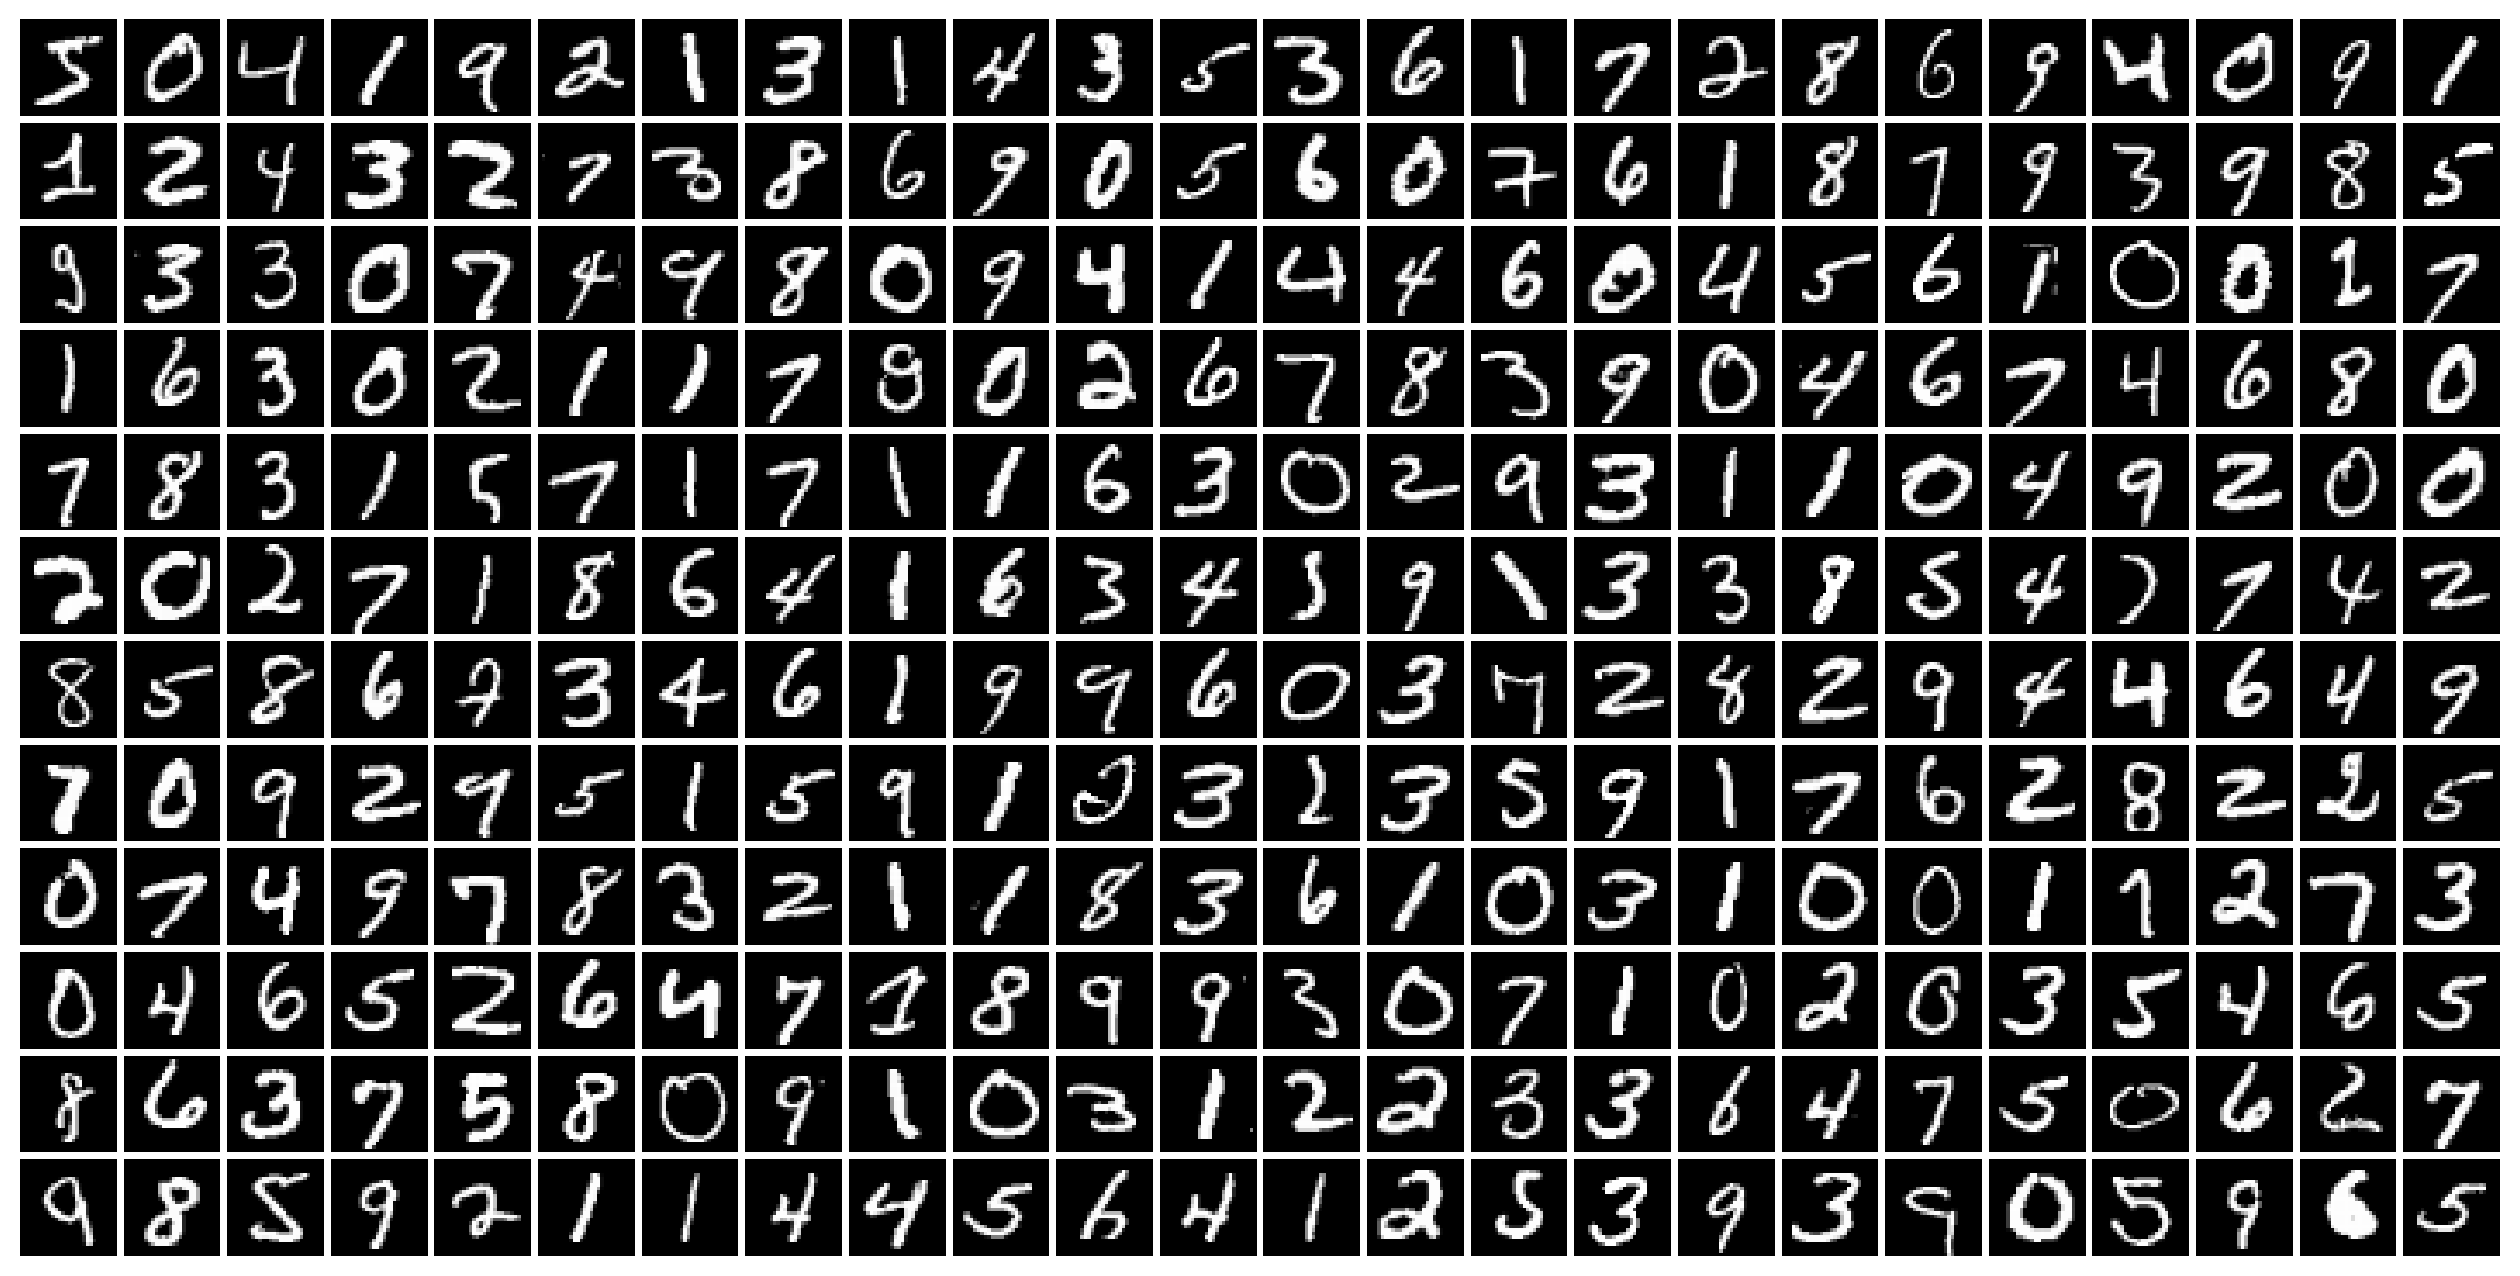

In [9]:
from mnists import MNIST

mnist = MNIST()

PREVIEW_N_ROWS = 12
PREVIEW_N_COLS = 24
TILE_DIM = 28  # [px]


def create_mnist_digits(n_rows: int, n_cols: int, tile_dim: int) -> np.ndarray:
    shape = (n_rows, n_cols, tile_dim, tile_dim)
    return np.reshape(mnist.train_images()[: 12 * 24], newshape=shape)


mnist_digits = create_mnist_digits(PREVIEW_N_ROWS, PREVIEW_N_COLS, TILE_DIM)

tiles(mnist_digits)

# RBM & DBN training

In [10]:
class RestrictedBoltzmannMachine:
    """
    A Restricted Boltzmann Machine (RBM) with a single visible and hidden layer.

    The weight matrix W has shape (visible_size + 1, hidden_size + 1), where
    the extra row and column are reserved for bias units.

    Attributes:
        visible_size:       Number of visible (input) units, excluding the bias.
        hidden_size:        Number of hidden units, excluding the bias.
        visible_act_func:   The activation function used within visible layer.
        hidden_act_func:    The activation function used within hidden layer.
        learning_rate:      Step size used during contrastive divergence updates.
        W:                  Weight matrix of shape (visible_size+1, hidden_size+1).
        momentum:           Momentum coefficient.
        l2_penalty:         Coefficent for the L2 regularization.
    """

    def __init__(
        self,
        visible_size: int,
        hidden_size: int,
        visible_act_func: callable,
        hidden_act_func: callable,
        learning_rate: float,
        momentum: float,
        l2_penalty: float,
    ):
        self.visible_size = visible_size
        self.hidden_size = hidden_size

        self.visible_act_func = visible_act_func
        self.hidden_act_func = hidden_act_func

        self.learning_rate = learning_rate
        self.momentum = momentum

        self.l2_penalty = l2_penalty

        self.reset()

    def reset(self) -> None:
        self.W = np.random.normal(
            scale=0.01, size=(self.visible_size + 1, self.hidden_size + 1)
        ).astype(np.float32)
        self.W[:, -1] = 0.0  # zero hidden-bias weights
        self.W[-1, :] = 0.0  # zero visible-bias weights
        self.M = zeros(self.visible_size + 1, self.hidden_size + 1)

In [11]:
from typing import TypeAlias

DBN: TypeAlias = list[RestrictedBoltzmannMachine]

In [12]:
def cdk(rbm, minibatch, k=1):
    observations_count = minibatch.shape[0]

    positive_visible = minibatch
    negative_visible = append_ones(zeros(observations_count, rbm.visible_size))

    positive_hidden = append_ones(zeros(observations_count, rbm.hidden_size))
    negative_hidden = append_ones(zeros(observations_count, rbm.hidden_size))

    z = minibatch @ rbm.W[:, :-1]
    positive_hidden[:, :-1] = rbm.hidden_act_func(z)
    negative_hidden[:, :-1] = rbm.hidden_act_func(z, stochastic=True)

    for cd_i in range(k):
        negative_visible[:, :-1] = rbm.visible_act_func(
            negative_hidden @ rbm.W[:-1, :].T, stochastic=True
        )
        z = negative_visible @ rbm.W[:, :-1]
        if cd_i < (k - 1):
            negative_hidden[:, :-1] = rbm.hidden_act_func(z, stochastic=True)
        else:
            negative_hidden[:, :-1] = rbm.hidden_act_func(z)

    rbm.M *= rbm.momentum
    rbm.M += (
        (rbm.learning_rate / observations_count) * positive_visible.T @ positive_hidden
    )
    rbm.M -= (
        (rbm.learning_rate / observations_count) * negative_visible.T @ negative_hidden
    )

    if rbm.l2_penalty is not None:
        rbm.M[:-1, :-1] = (
            rbm.M[:-1, :-1] - rbm.learning_rate * rbm.l2_penalty * rbm.W[:-1, :-1]
        )

    rbm.W += rbm.M


def reconstuction_error(rbm, minibatch):
    observations_count = minibatch.shape[0]
    visible = zeros(observations_count, rbm.visible_size)
    hidden = append_ones(zeros(observations_count, rbm.hidden_size))

    hidden[:, :-1] = rbm.hidden_act_func(minibatch @ rbm.W[:, :-1])
    hidden[:, :-1] = hidden[:, :-1] > rand(observations_count, rbm.hidden_size)

    visible = rbm.visible_act_func(hidden @ np.transpose(rbm.W[:-1, :]))

    error = minibatch[:, :-1] - visible
    error = np.sum(np.square(error)) / observations_count

    return error

In [13]:
def propagate_up(dbn, layers_count, visible):
    for i in range(layers_count):
        visible = append_ones(dbn[i].visible_act_func(visible @ dbn[i].W[:, :-1]))
    return visible


def propagate_down(dbn, layers_count, hidden):
    for i in reversed(range(layers_count)):
        hidden = append_ones(
            dbn[i].hidden_act_func(hidden @ np.transpose(dbn[i].W[:-1, :]))
        )
    return hidden


def dbn_reconstuction_error(dbn, layer_idx, minibatch):
    propagated = propagate_up(dbn, layer_idx, minibatch)
    error = reconstuction_error(dbn[layer_idx], propagated)
    return error


def train_dbn_layer(dbn, layer_idx, dataset, batch_size):
    dataset = propagate_up(dbn, layer_idx, dataset)

    batches_limit = dataset.shape[0] / batch_size
    for batch_idx, batch in enumerate(chunks(dataset, batch_size)):
        cdk(dbn[layer_idx], batch)
        if batch_idx % round(batches_limit / 40) == 0:
            print("#", end="")


def train_dbn(dbn, dataset, monitoring_set, batch_size, epochs_count):
    for layer_idx in range(len(dbn)):
        print("\nLearning layer {}".format(layer_idx))

        for epoch in range(epochs_count):
            print("Epoch {}:".format(epoch + 1), end="\t")

            if epoch == 5:
                dbn[layer_idx].momentum = 0.9

            start_time = time.time()
            train_dbn_layer(dbn, layer_idx, dataset, batch_size)
            elapsed = time.time() - start_time

            error = dbn_reconstuction_error(dbn, layer_idx, monitoring_set)
            print(
                "\telapsed: {0:>2.2f}s, reconstruction error: {1:>2.2f}".format(
                    elapsed, error
                )
            )

# Part 1. Autoencoder training with Nesterov accelerated gradient descend

In [14]:
class Layer:
    def __init__(
        self,
        visible_size: int,
        hidden_size: int,
        activation_fun,
        d_activation_fun,
        learning_rate: float,
        momentum: float,
        l2_penalty: float,
    ):
        self.visible_size = visible_size
        self.hidden_size = hidden_size

        self.activation_fun = activation_fun
        self.d_activation_fun = d_activation_fun

        self.learning_rate = learning_rate
        self.momentum = momentum

        self.l2_penalty = l2_penalty

        self.reset()

    def reset(self) -> None:
        self.W = np.random.normal(
            scale=0.01, size=(self.visible_size + 1, self.hidden_size)
        ).astype(np.float32)
        self.W[-1, :] = 0.0  # biases

        self.activations = None
        self.d_activations = None
        self.deltas = None

        self.M = zeros(self.visible_size + 1, self.hidden_size)

In [15]:
from typing import TypeAlias

MLP: TypeAlias = list[Layer]

## Error backpropagation with Nesterov accelerated gradient descend

__Forward pass.__ When ```compute_derivatives == false```, we are not training the network but use it to make predictions. In this case we cannot use weights in ```layer.W``` directly: in Nesterov method weights in this matrix are shifted along the direction of momentum (that is, they are at the point in the weight space where the gradient is calculated). We need to account for this when calculating the total input to the next layer.

In [16]:
def forward_pass(ae, batch, compute_derivatives):
    visible = batch

    for layer_idx, layer in enumerate(ae):
        if not compute_derivatives:
            # We are using the network to make predictions. Fix evaluation of the total
            # input to the next layer (z) so that it uses the correct weights, and not
            # the weights where the gradient is calculated.

            z = visible @ (layer.W - layer.momentum * layer.M)
        else:
            z = visible @ layer.W

        layer.activations = append_ones(layer.activation_fun(z))

        if compute_derivatives and (layer_idx < len(ae) - 1):
            layer.d_activations = layer.d_activation_fun(z)

        visible = layer.activations

    return visible[:, :-1]

__Backward pass.__ Implement Nesterov updates in the backward pass of error backpropagation.

Remember that the weights in ```layer.W``` are shifted along the direction of momentum. Before we change the momentum matrix (but after we have everything needed to calculate the gradient), we must fix (i.e. _un-shift_) these weights.

At the end of the backward pass, we must update the weight matrix accoring to the momentum interpretation of the Nesterov method.

In [17]:
def error_backpropagate(ae, batch):
    observations_count = batch.shape[0]

    for layer_idx, layer in reversed(list(enumerate(ae))):
        if layer_idx > 0:
            prev_layer = ae[layer_idx - 1]
            visible = prev_layer.activations

            prev_layer.deltas = (
                layer.deltas @ layer.W[:-1, :].T
            ) * prev_layer.d_activations
        else:
            visible = batch

        # Fix weights in layer.W before changing the momentum matrix
        layer.W = layer.W - layer.momentum * layer.M

        layer.M *= layer.momentum
        layer.M -= (layer.learning_rate / observations_count) * (
            visible.T @ layer.deltas
        )

        if layer.l2_penalty > 0:
            layer.M[:-1, :] = (
                layer.M[:-1, :]
                - layer.learning_rate * layer.l2_penalty * layer.W[:-1, :]
            )

        # Update the weight matrix according to the momentum interpretation of the Nesterov method.
        layer.W = layer.W + (1 + layer.momentum) * layer.M

### Cross entropy cost

In [18]:
def xentropy(batch, reconstructions):
    observations_count = batch.shape[0]

    xe = batch * np.log(reconstructions) + (ones(*batch.shape) - batch) * np.log(
        ones(*reconstructions.shape) - reconstructions
    )
    xe = -np.sum(xe, axis=1)
    return np.sum(xe, axis=0) / observations_count

### Training procedure

In [19]:
def train_ae(ae: MLP, dataset: np.ndarray, batch_size: np.ndarray) -> None:
    batches_limit = dataset.shape[0] / batch_size
    batched_data = chunks(dataset, batch_size)

    for batch_idx, batch in enumerate(batched_data):
        reconstructions = forward_pass(ae, batch, True)

        ae[-1].deltas = reconstructions - batch[:, :-1]

        error_backpropagate(ae, batch)

        if batch_idx % round(batches_limit / 40) == 0:
            print("#", end="")

In [20]:
def run_ae_training(ae, train_set, validation_set, batch_size, epochs_count):
    for epoch in range(epochs_count):
        print("Epoch {}:".format(epoch + 1), end="\t")

        if epoch == 10:
            for layer in ae:
                layer.momentum = 0.95
        elif epoch == 15:
            for layer in ae:
                layer.momentum = 0.97
        elif epoch == 20:
            for layer in ae:
                layer.momentum = 0.98
        elif epoch == 25:
            for layer in ae:
                layer.momentum = 0.99

        start_time = time.time()
        train_ae(ae, train_set, batch_size)
        elapsed = time.time() - start_time

        xe = xentropy(validation_set[:, :-1], forward_pass(ae, validation_set, False))
        print("\telapsed: {0:>2.2f}s, cross-entropy: {1:>2.2f}".format(elapsed, xe))

    print("Training finished!")

###  Initializing AE with DBN weights

In [21]:
def initialize_ae(ae: MLP, dbn: DBN) -> None:
    assert len(ae) == 2 * len(dbn)

    n = len(dbn)
    for layer_idx in range(n):
        ae[layer_idx].W = np.copy(dbn[layer_idx].W[:, :-1])
        ae[n + layer_idx].W = np.copy(dbn[n - layer_idx - 1].W[:-1, :].T)

## Autoencoder for MNIST digits

In [22]:
DATASET_SIZE = 10000  # 60000 for whole dataset
DIGIT_SIZE = 28

##### Train set #####

mnist_train_images = mnist.train_images().astype(np.float32) / 255.0
mnist_train_images = np.random.permutation(mnist_train_images)

mnist_train_images = np.reshape(
    mnist_train_images[:DATASET_SIZE], newshape=(DATASET_SIZE, DIGIT_SIZE * DIGIT_SIZE)
)
mnist_train_images = append_ones(mnist_train_images)

monitoring_set_indeces = np.random.choice(
    mnist_train_images.shape[0], 512, replace=False
)
monitoring_set = mnist_train_images[monitoring_set_indeces]

##### Test set #####

mnist_test_images = mnist.test_images().astype(np.float32) / 255.0
mnist_test_images = np.reshape(
    mnist_test_images, newshape=(-1, DIGIT_SIZE * DIGIT_SIZE)
)
mnist_test_images = append_ones(mnist_test_images)

In [23]:
VISIBLE_LAYER_SIZE = DIGIT_SIZE * DIGIT_SIZE

BATCH_SIZE = 128
EPOCHS_COUNT = 50

RBM_LEARNING_RATE = 0.1
AE_LEARNING_RATE = 0.01
AE_MOMENTUM = 0.9
L2_PENALTY = 0.0002

In [24]:
from IPython.core.display import HTML


def compare_results(
    ae, dbn, train_set, validation_set, monitoring_set, batch_size, epochs_count
):
    for layer in ae:
        layer.reset()

    display(HTML("<h3>DBN training</h3>"))
    train_dbn(dbn, train_set, monitoring_set, batch_size, epochs_count)

    initialize_ae(ae, dbn)
    dbn_reconstructions = np.reshape(
        forward_pass(ae, validation_set[: 8 * 24, :], False), newshape=(8, 24, 28, 28)
    )
    dbn_rec_cost = xentropy(
        validation_set[:, :-1], forward_pass(ae, validation_set, False)
    )

    display(HTML("<h3>Finetuning pretrained AE</h3>"))

    print("Reconstruction cost before finetuning: {0:>2.2f}\n".format(dbn_rec_cost))
    run_ae_training(ae, train_set, validation_set, batch_size, epochs_count)

    display(HTML("<h3>Input minibatch</h3>"))
    tiles(np.reshape(validation_set[: 8 * 24, :-1], newshape=(8, 24, 28, 28)))

    display(HTML("<h3>Pretrained AE reconstructions</h3>"))
    tiles(dbn_reconstructions)

    display(HTML("<h3>Finetuned AE reconstructions</h3>"))
    ae_reconstructions = np.reshape(
        forward_pass(ae, validation_set[: 8 * 24], False), newshape=(8, 24, 28, 28)
    )
    tiles(ae_reconstructions)

###  Autoencoder network

Define the autoencoder network for MNIST digits. The network structure should be suitable for pretraining with the provided DBN.


Learning layer 0
Epoch 1:	########################################	elapsed: 0.43s, reconstruction error: 31.65
Epoch 2:	########################################	elapsed: 0.31s, reconstruction error: 24.73
Epoch 3:	########################################	elapsed: 0.31s, reconstruction error: 21.31
Epoch 4:	########################################	elapsed: 0.41s, reconstruction error: 19.00
Epoch 5:	########################################	elapsed: 0.38s, reconstruction error: 17.69
Epoch 6:	########################################	elapsed: 0.37s, reconstruction error: 15.37
Epoch 7:	########################################	elapsed: 0.36s, reconstruction error: 13.64
Epoch 8:	########################################	elapsed: 0.38s, reconstruction error: 12.68
Epoch 9:	########################################	elapsed: 0.40s, reconstruction error: 11.93
Epoch 10:	########################################	elapsed: 0.33s, reconstruction error: 11.59
Epoch 11:	###############################

Reconstruction cost before finetuning: 138.17

Epoch 1:	########################################	elapsed: 0.58s, cross-entropy: 108.93
Epoch 2:	########################################	elapsed: 0.56s, cross-entropy: 105.08
Epoch 3:	########################################	elapsed: 0.55s, cross-entropy: 102.84
Epoch 4:	########################################	elapsed: 0.57s, cross-entropy: 101.29
Epoch 5:	########################################	elapsed: 0.55s, cross-entropy: 100.11
Epoch 6:	########################################	elapsed: 0.57s, cross-entropy: 99.15
Epoch 7:	########################################	elapsed: 0.53s, cross-entropy: 98.36
Epoch 8:	########################################	elapsed: 0.52s, cross-entropy: 97.67
Epoch 9:	########################################	elapsed: 0.53s, cross-entropy: 97.07
Epoch 10:	########################################	elapsed: 0.57s, cross-entropy: 96.54
Epoch 11:	########################################	elapsed: 0.51s, cross-entr

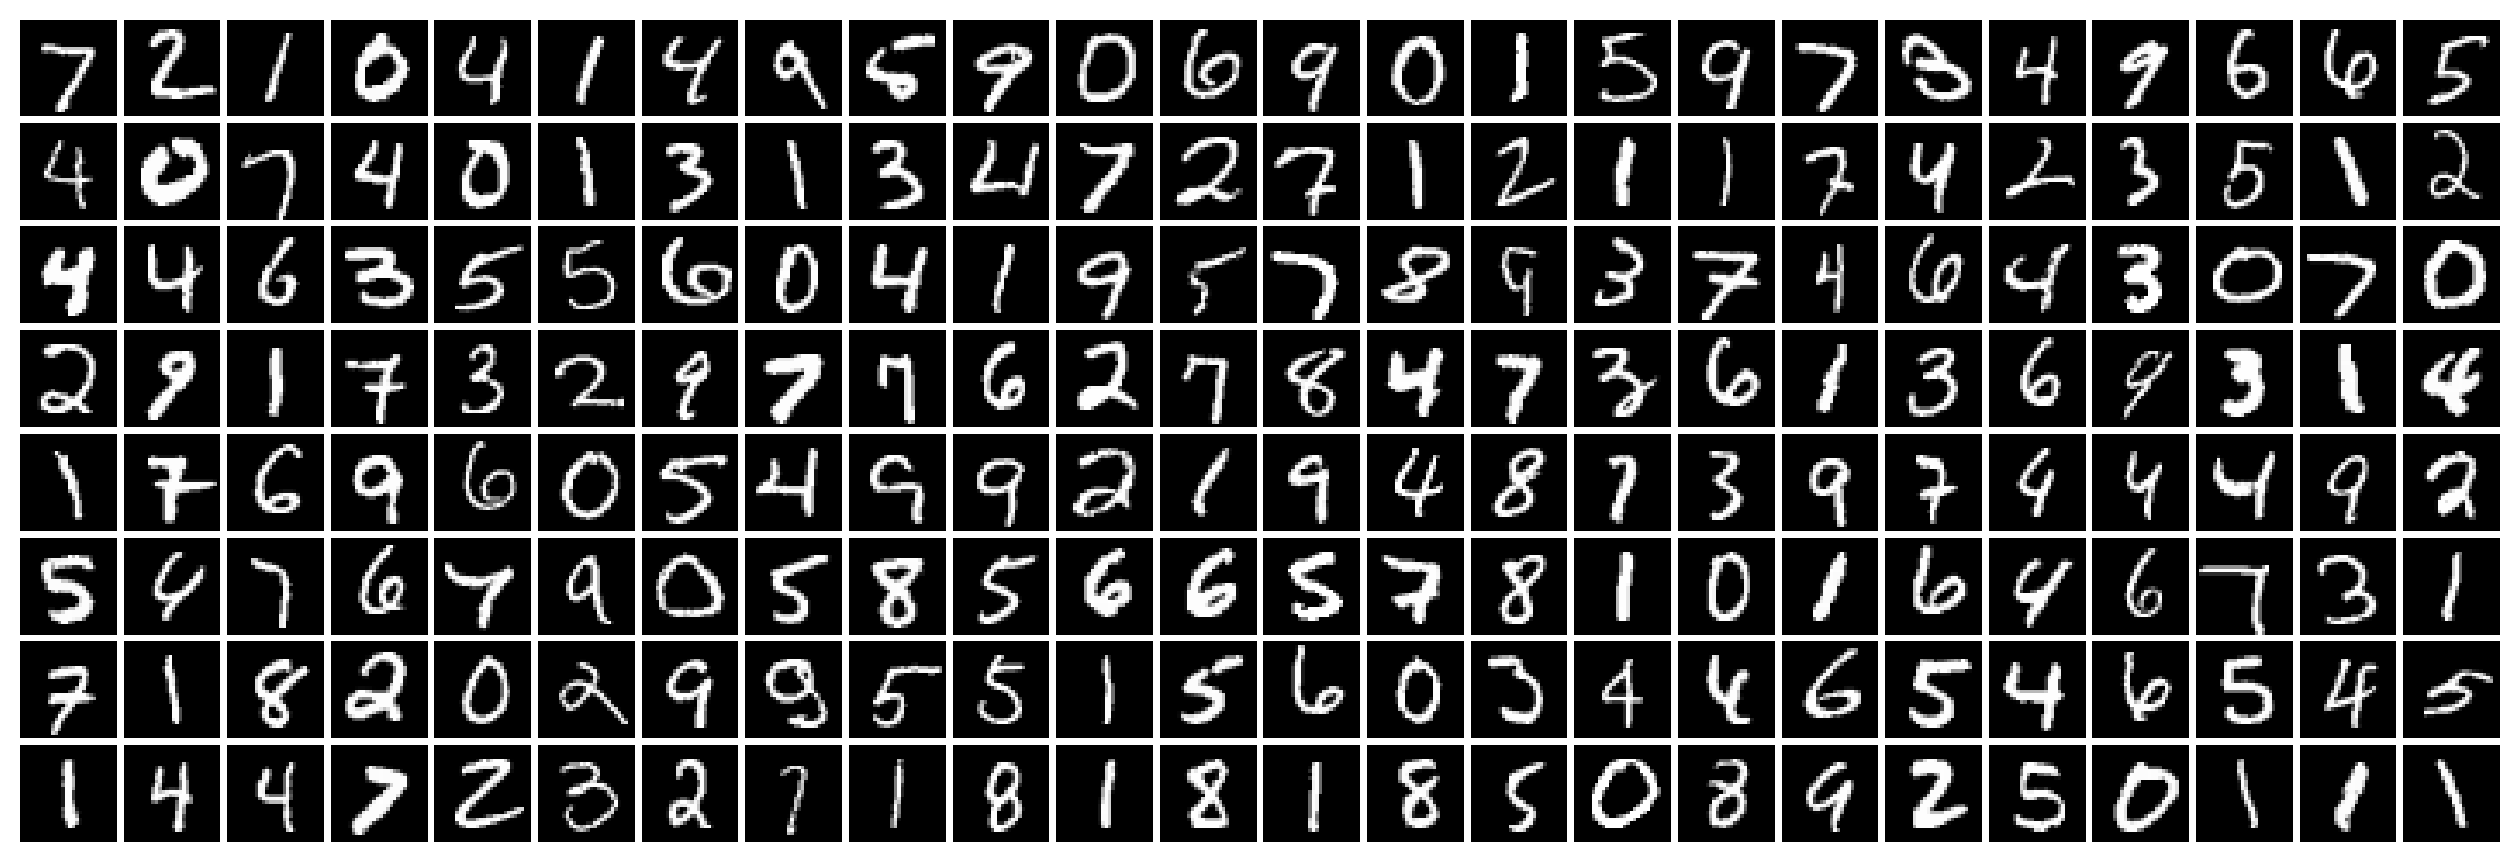

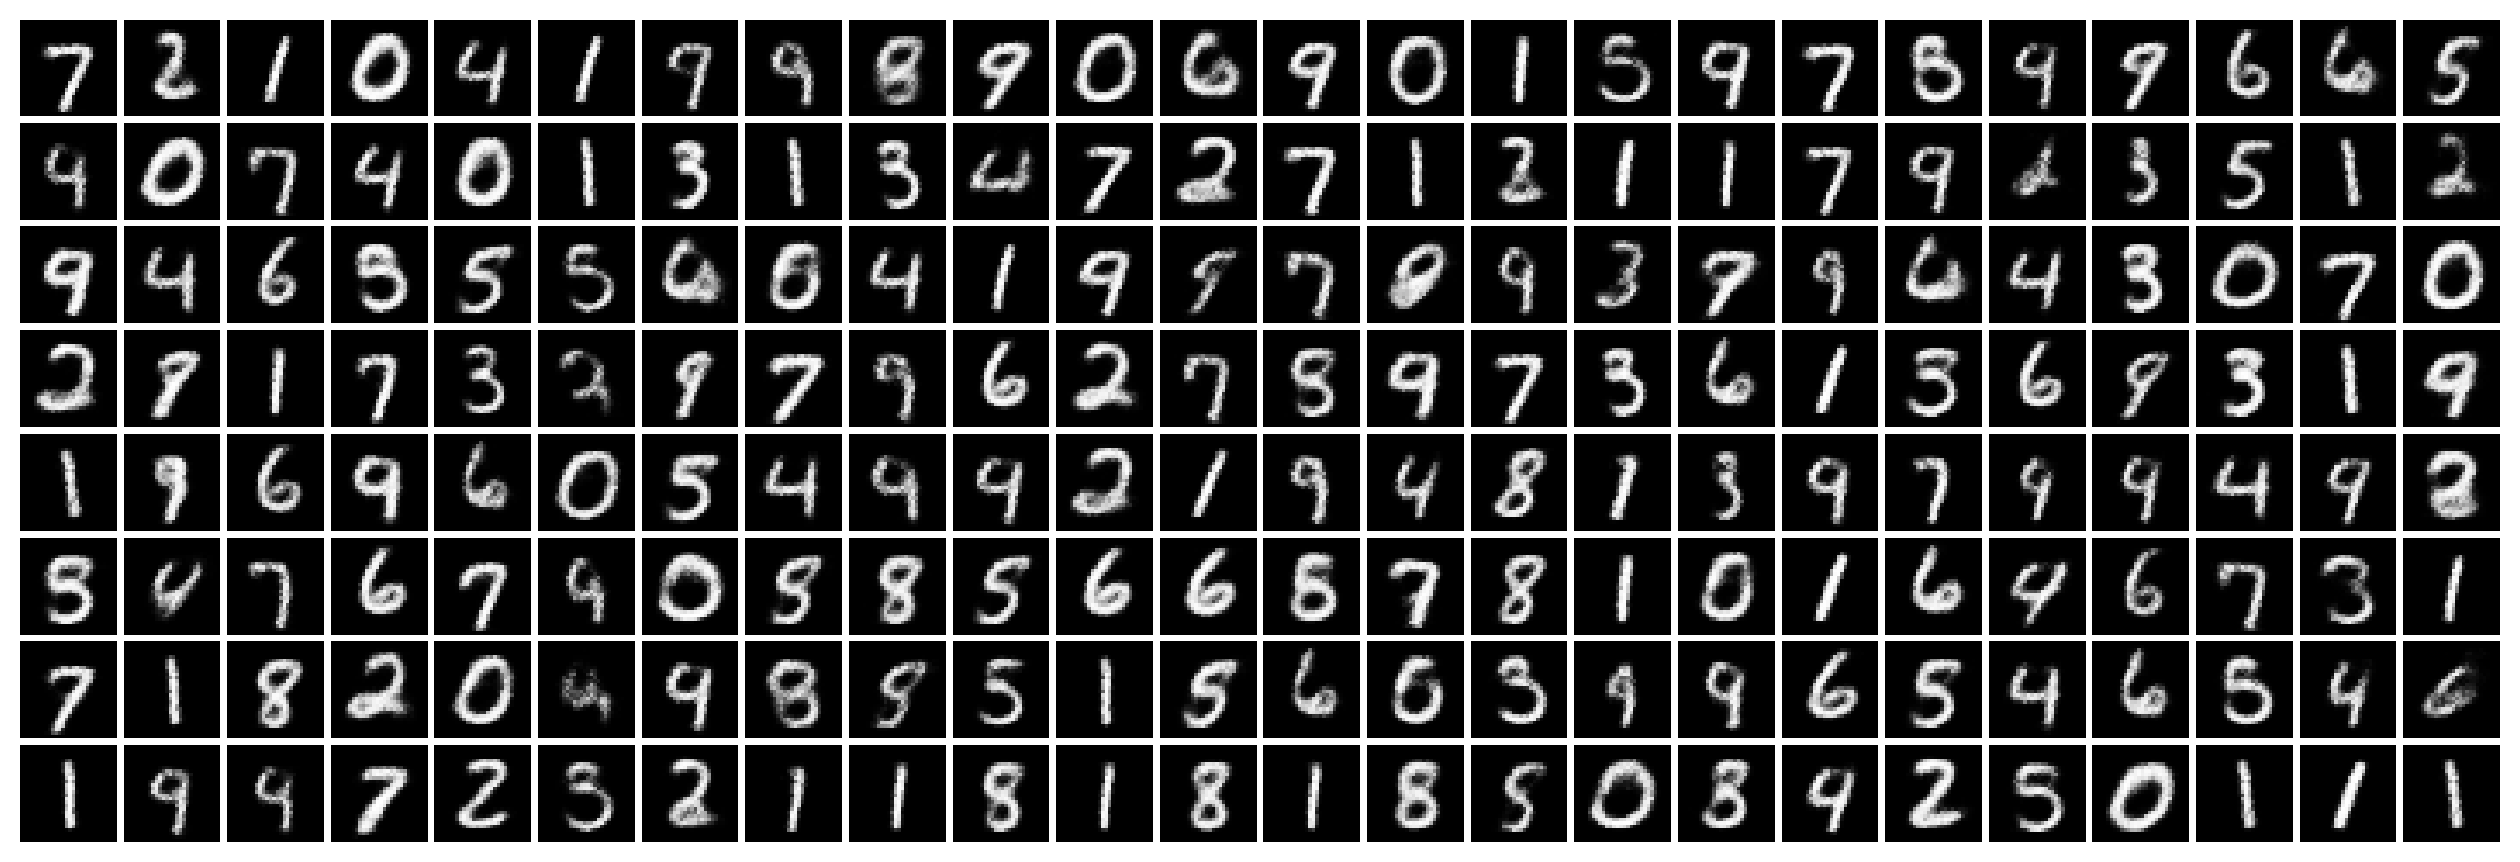

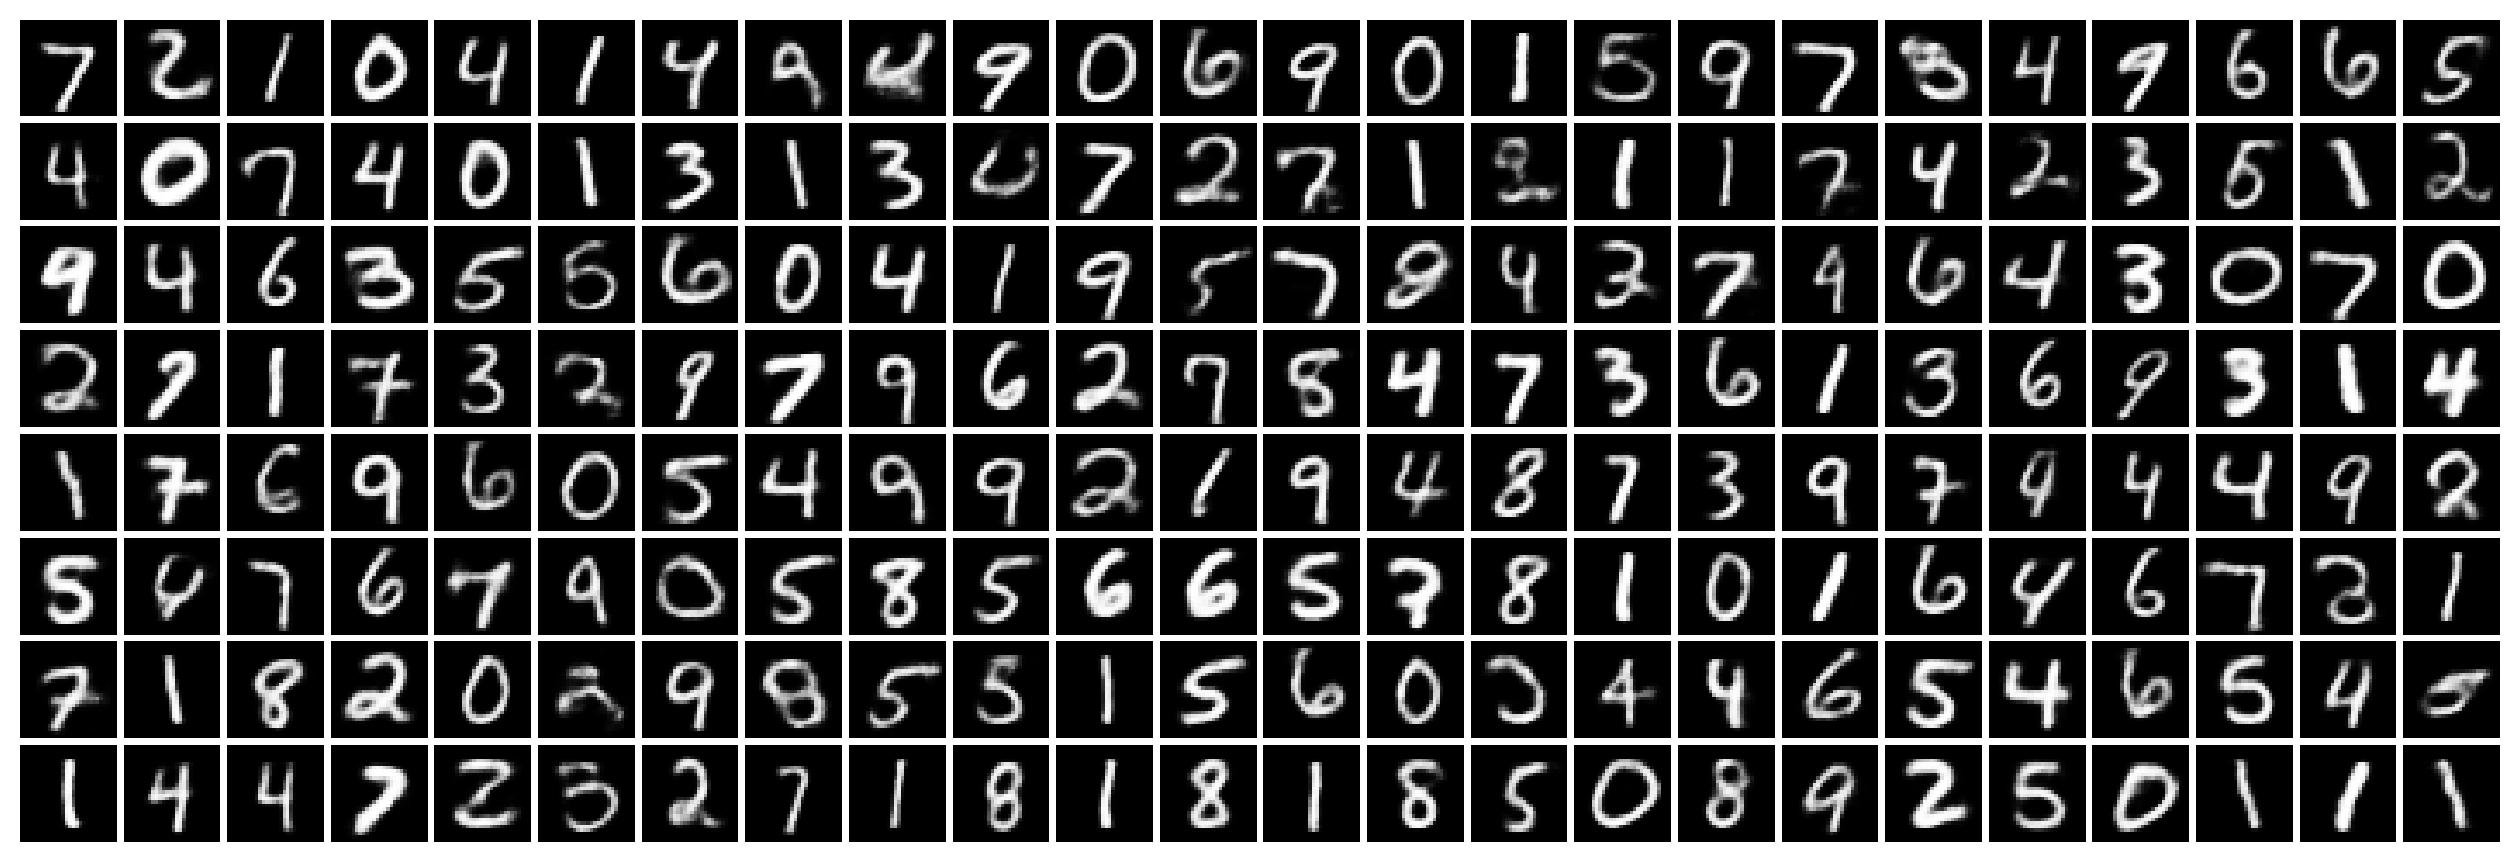

In [25]:
dbn = [
    RestrictedBoltzmannMachine(
        VISIBLE_LAYER_SIZE, 256, sigmoid, sigmoid, RBM_LEARNING_RATE, 0.5, L2_PENALTY
    ),
    RestrictedBoltzmannMachine(
        256, 128, sigmoid, sigmoid, RBM_LEARNING_RATE, 0.5, L2_PENALTY
    ),
    RestrictedBoltzmannMachine(
        128, 64, sigmoid, sigmoid, RBM_LEARNING_RATE, 0.5, L2_PENALTY
    ),
    RestrictedBoltzmannMachine(
        64, 10, sigmoid, gaussian, RBM_LEARNING_RATE / 10.0, 0.5, L2_PENALTY
    ),
]

ae: MLP = [
    # encoder
    Layer(
        VISIBLE_LAYER_SIZE,
        256,
        sigmoid,
        sigmoid_derivative,
        AE_LEARNING_RATE,
        AE_MOMENTUM,
        L2_PENALTY,
    ),
    Layer(
        256, 128, sigmoid, sigmoid_derivative, AE_LEARNING_RATE, AE_MOMENTUM, L2_PENALTY
    ),
    Layer(
        128, 64, sigmoid, sigmoid_derivative, AE_LEARNING_RATE, AE_MOMENTUM, L2_PENALTY
    ),
    Layer(
        64,
        10,
        gaussian,
        gaussian_derivative,
        AE_LEARNING_RATE / 10.0,
        AE_MOMENTUM,
        L2_PENALTY,
    ),
    # decoder (mirrored)
    Layer(
        10,
        64,
        sigmoid,
        sigmoid_derivative,
        AE_LEARNING_RATE / 10.0,
        AE_MOMENTUM,
        L2_PENALTY,
    ),
    Layer(
        64, 128, sigmoid, sigmoid_derivative, AE_LEARNING_RATE, AE_MOMENTUM, L2_PENALTY
    ),
    Layer(
        128, 256, sigmoid, sigmoid_derivative, AE_LEARNING_RATE, AE_MOMENTUM, L2_PENALTY
    ),
    Layer(
        256,
        VISIBLE_LAYER_SIZE,
        sigmoid,
        sigmoid_derivative,
        AE_LEARNING_RATE,
        AE_MOMENTUM,
        L2_PENALTY,
    ),
]

compare_results(
    ae,
    dbn,
    mnist_train_images,
    mnist_test_images,
    monitoring_set,
    BATCH_SIZE,
    EPOCHS_COUNT,
)

# Part 2. Visualization of MNIST digits with an autoencoder

In [26]:
def run_2d_ae_training(ae, train_set, validation_set, batch_size, epochs_count):
    for epoch in range(epochs_count):
        print("Epoch {}:".format(epoch + 1), end="\t")

        if epoch == 10:
            for layer in ae:
                layer.momentum = 0.8
        elif epoch == 30:
            for layer in ae:
                layer.momentum = 0.9

        start_time = time.time()
        train_ae(ae, train_set, batch_size)
        elapsed = time.time() - start_time

        xe = xentropy(validation_set[:, :-1], forward_pass(ae, validation_set, False))
        print("\telapsed: {0:>2.2f}s, cross-entropy: {1:>2.2f}".format(elapsed, xe))

    print("Training finished!")

In [27]:
def plot_2d_mnist_scatter(X, y):
    fig, plot = plt.subplots()
    fig.set_size_inches(16, 16)
    plt.prism()

    for i in range(10):
        digit_indeces = y == i
        dim1 = X[digit_indeces, 0]
        dim2 = X[digit_indeces, 1]
        plot.scatter(dim1, dim2, label=str(i))

    plot.set_xticks(())
    plot.set_yticks(())

    plt.tight_layout()
    plt.legend()
    plt.show()

In [28]:
from IPython.core.display import HTML


def compare_2d_visualizations(
    ae,
    dbn,
    train_set,
    validation_set,
    validation_labels,
    monitoring_set,
    batch_size,
    epochs_count,
):
    for layer in ae:
        layer.reset()

    display(HTML("<h3>DBN training</h3>"))
    train_dbn(dbn, train_set, monitoring_set, batch_size, epochs_count)

    initialize_ae(ae, dbn)
    dbn_rec_cost = xentropy(
        validation_set[:, :-1], forward_pass(ae, validation_set, False)
    )

    _ = forward_pass(ae, validation_set, False)
    dbn_codes = ae[3].activations[:, :-1]

    display(HTML("<h3>Finetuning pretrained AE</h3>"))

    print("Reconstruction cost before finetuning: {0:>2.2f}\n".format(dbn_rec_cost))
    run_2d_ae_training(ae, train_set, validation_set, batch_size, epochs_count)

    _ = forward_pass(ae, validation_set, False)
    ae_codes = ae[3].activations[:, :-1]

    display(HTML("<h3>2D codes from the pretrained AE</h3>"))
    plot_2d_mnist_scatter(dbn_codes, validation_labels)

    display(HTML("<h3>2D codes from the finetuned AE</h3>"))
    plot_2d_mnist_scatter(ae_codes, validation_labels)

In [29]:
DATASET_SIZE = 20000  # 60000 for whole dataset
DIGIT_SIZE = 28

##### Train set #####

mnist_train_images = mnist.train_images().astype(np.float32) / 255.0
mnist_train_images = np.random.permutation(mnist_train_images)

mnist_train_images = np.reshape(
    mnist_train_images[:DATASET_SIZE], newshape=(DATASET_SIZE, DIGIT_SIZE * DIGIT_SIZE)
)
mnist_train_images = append_ones(mnist_train_images)

monitoring_set_indeces = np.random.choice(
    mnist_train_images.shape[0], 512, replace=False
)
monitoring_set = mnist_train_images[monitoring_set_indeces]

##### Test set #####

mnist_test_images = mnist.test_images().astype(np.float32) / 255.0
mnist_test_images = np.reshape(
    mnist_test_images, newshape=(-1, DIGIT_SIZE * DIGIT_SIZE)
)
mnist_test_images = append_ones(mnist_test_images)
mnist_test_labels = mnist.test_labels()

In [30]:
VISIBLE_LAYER_SIZE = DIGIT_SIZE * DIGIT_SIZE

BATCH_SIZE = 128
EPOCHS_COUNT = 50

RBM_LEARNING_RATE = 0.1
AE_LEARNING_RATE = 0.01
AE_MOMENTUM = 0.5
L2_PENALTY = 0.0002

###  Autoencoder network for 2D visualization

Define the autoencoder network for MNIST digits. Use the network structure from the previous part, but change the size of the coding layer to 2 neurons.


Learning layer 0
Epoch 1:	########################################	elapsed: 0.64s, reconstruction error: 23.07
Epoch 2:	########################################	elapsed: 0.63s, reconstruction error: 17.89
Epoch 3:	########################################	elapsed: 0.65s, reconstruction error: 15.31
Epoch 4:	########################################	elapsed: 0.65s, reconstruction error: 13.97
Epoch 5:	########################################	elapsed: 0.65s, reconstruction error: 12.99
Epoch 6:	########################################	elapsed: 0.63s, reconstruction error: 11.96
Epoch 7:	########################################	elapsed: 0.63s, reconstruction error: 10.88
Epoch 8:	########################################	elapsed: 0.63s, reconstruction error: 10.37
Epoch 9:	########################################	elapsed: 0.65s, reconstruction error: 9.98
Epoch 10:	########################################	elapsed: 0.65s, reconstruction error: 9.83
Epoch 11:	#################################

Reconstruction cost before finetuning: 246.53

Epoch 1:	########################################	elapsed: 1.03s, cross-entropy: 170.56
Epoch 2:	########################################	elapsed: 1.10s, cross-entropy: 167.77
Epoch 3:	########################################	elapsed: 1.03s, cross-entropy: 165.99
Epoch 4:	########################################	elapsed: 1.04s, cross-entropy: 164.46
Epoch 5:	########################################	elapsed: 1.03s, cross-entropy: 163.05
Epoch 6:	########################################	elapsed: 1.11s, cross-entropy: 161.74
Epoch 7:	########################################	elapsed: 1.05s, cross-entropy: 160.58
Epoch 8:	########################################	elapsed: 1.25s, cross-entropy: 159.57
Epoch 9:	########################################	elapsed: 1.02s, cross-entropy: 158.67
Epoch 10:	########################################	elapsed: 1.05s, cross-entropy: 157.86
Epoch 11:	########################################	elapsed: 0.99s, cross

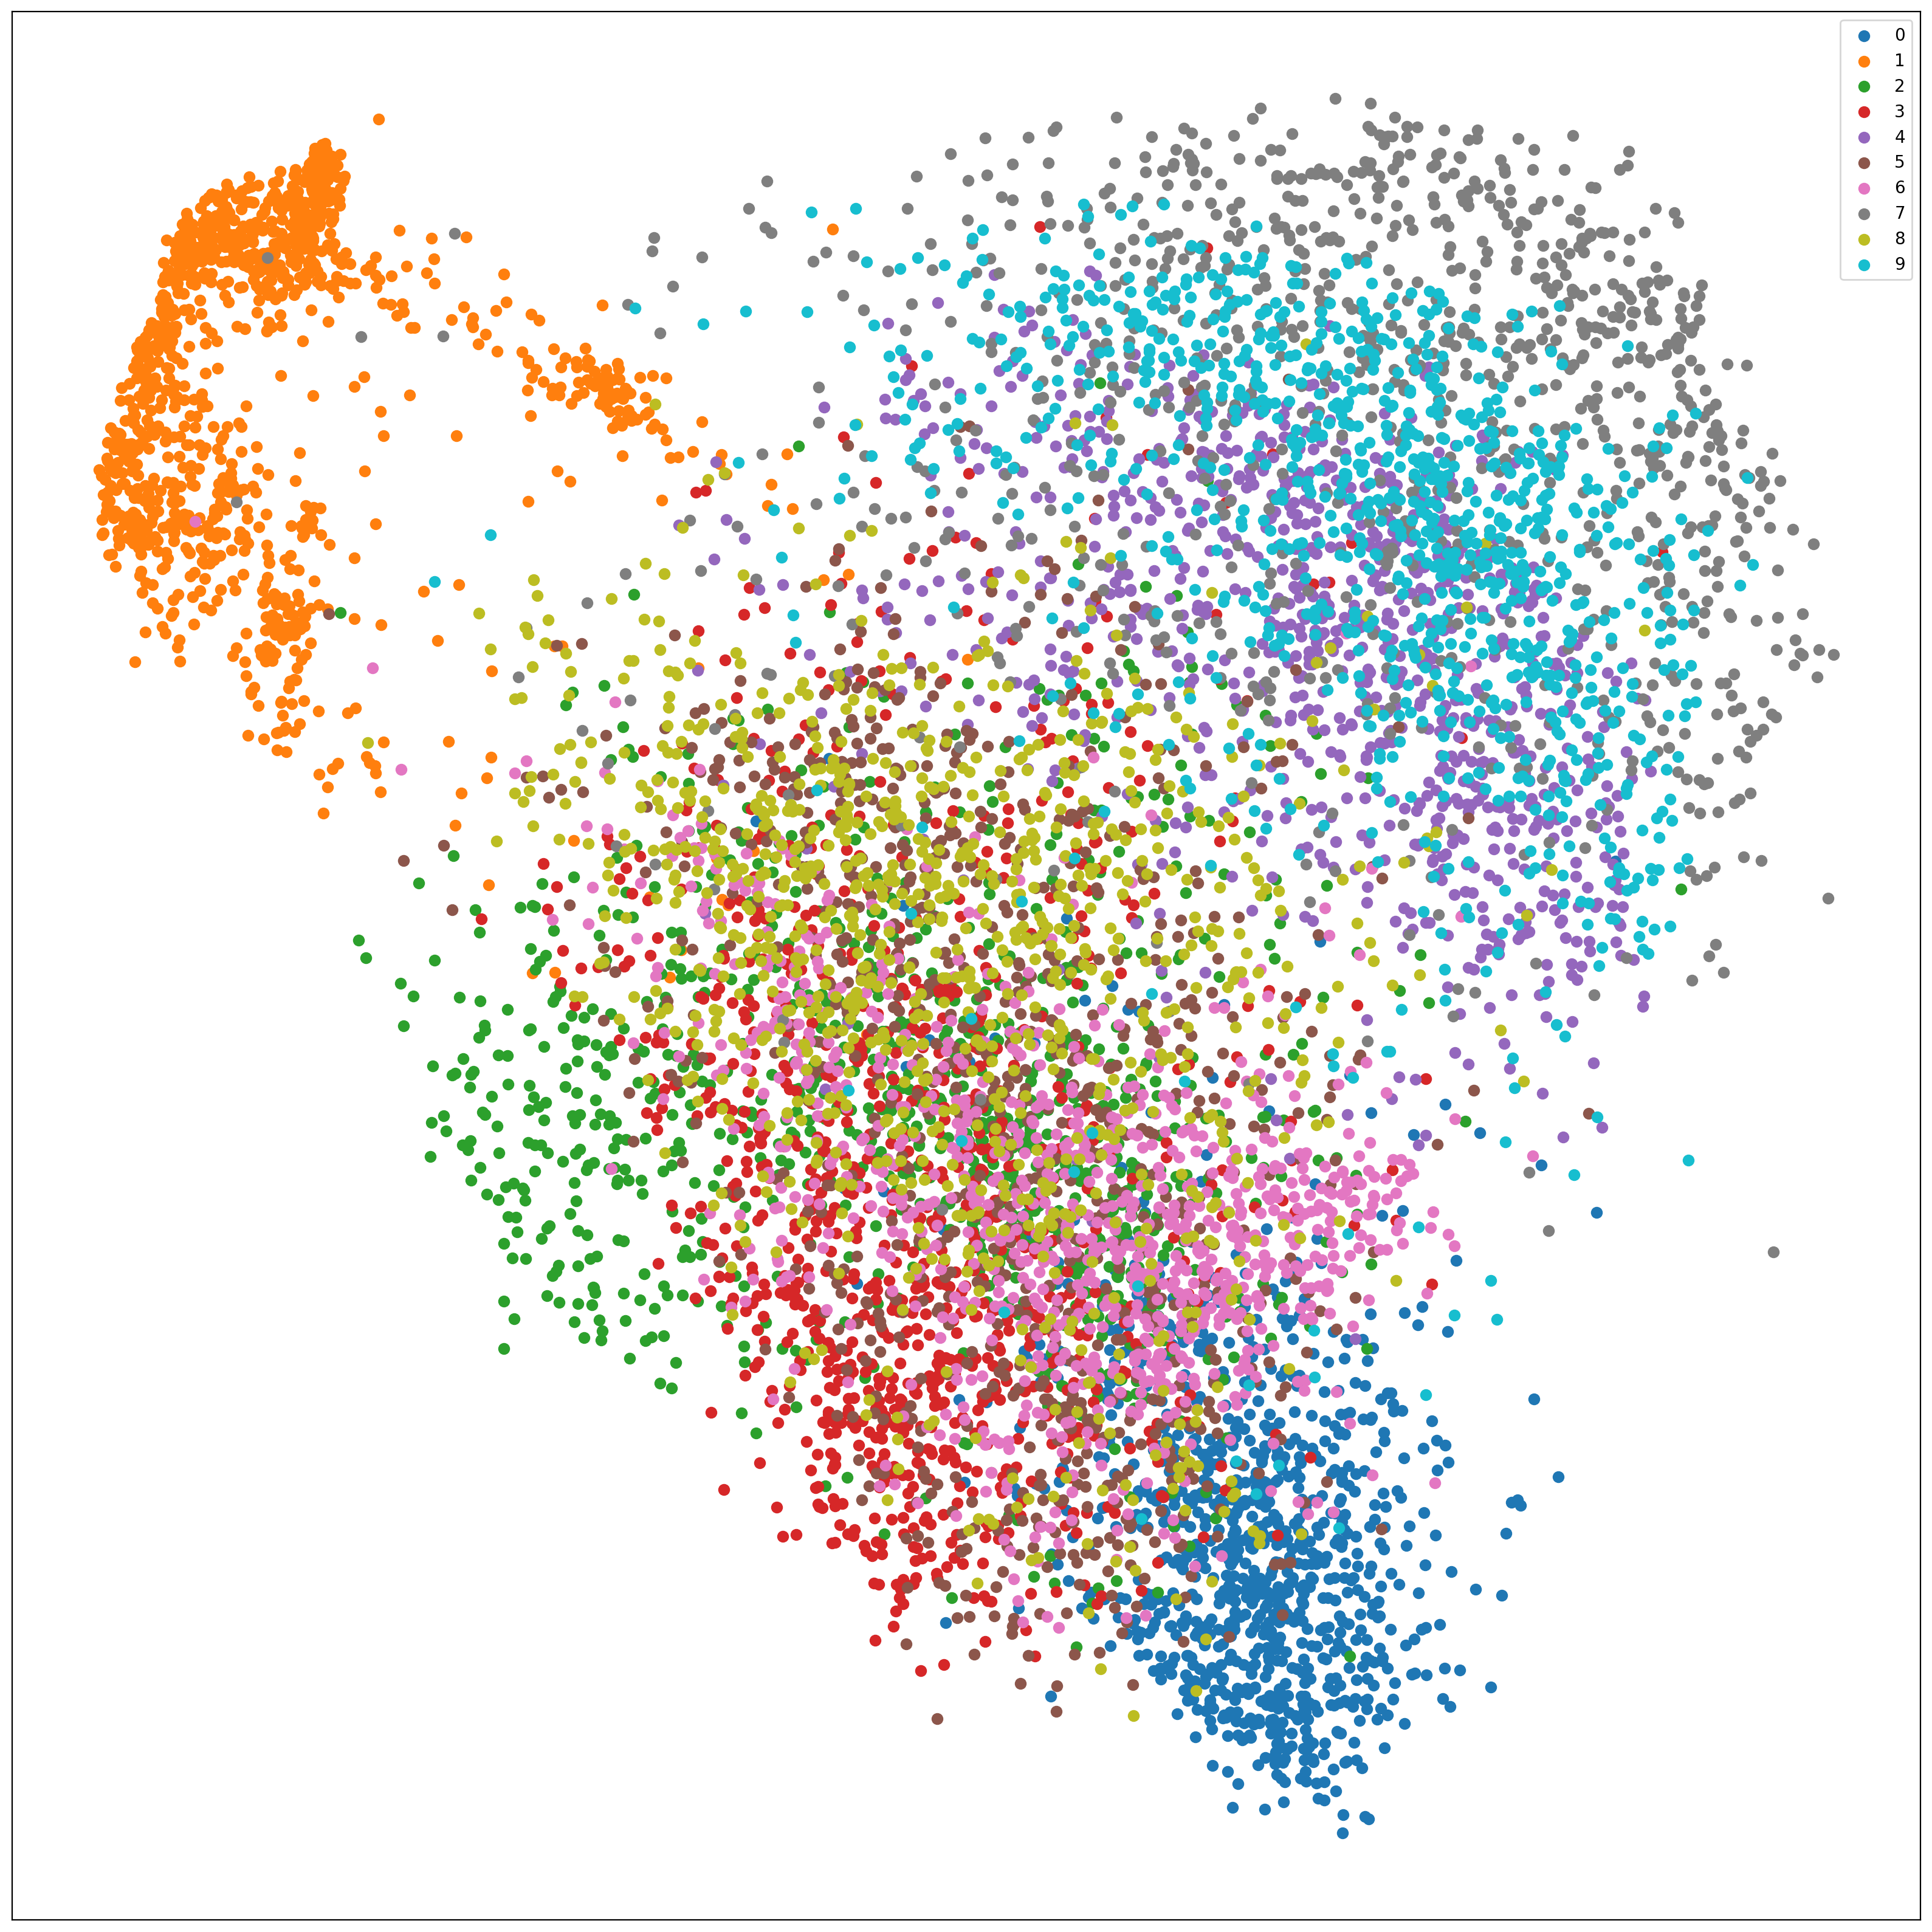

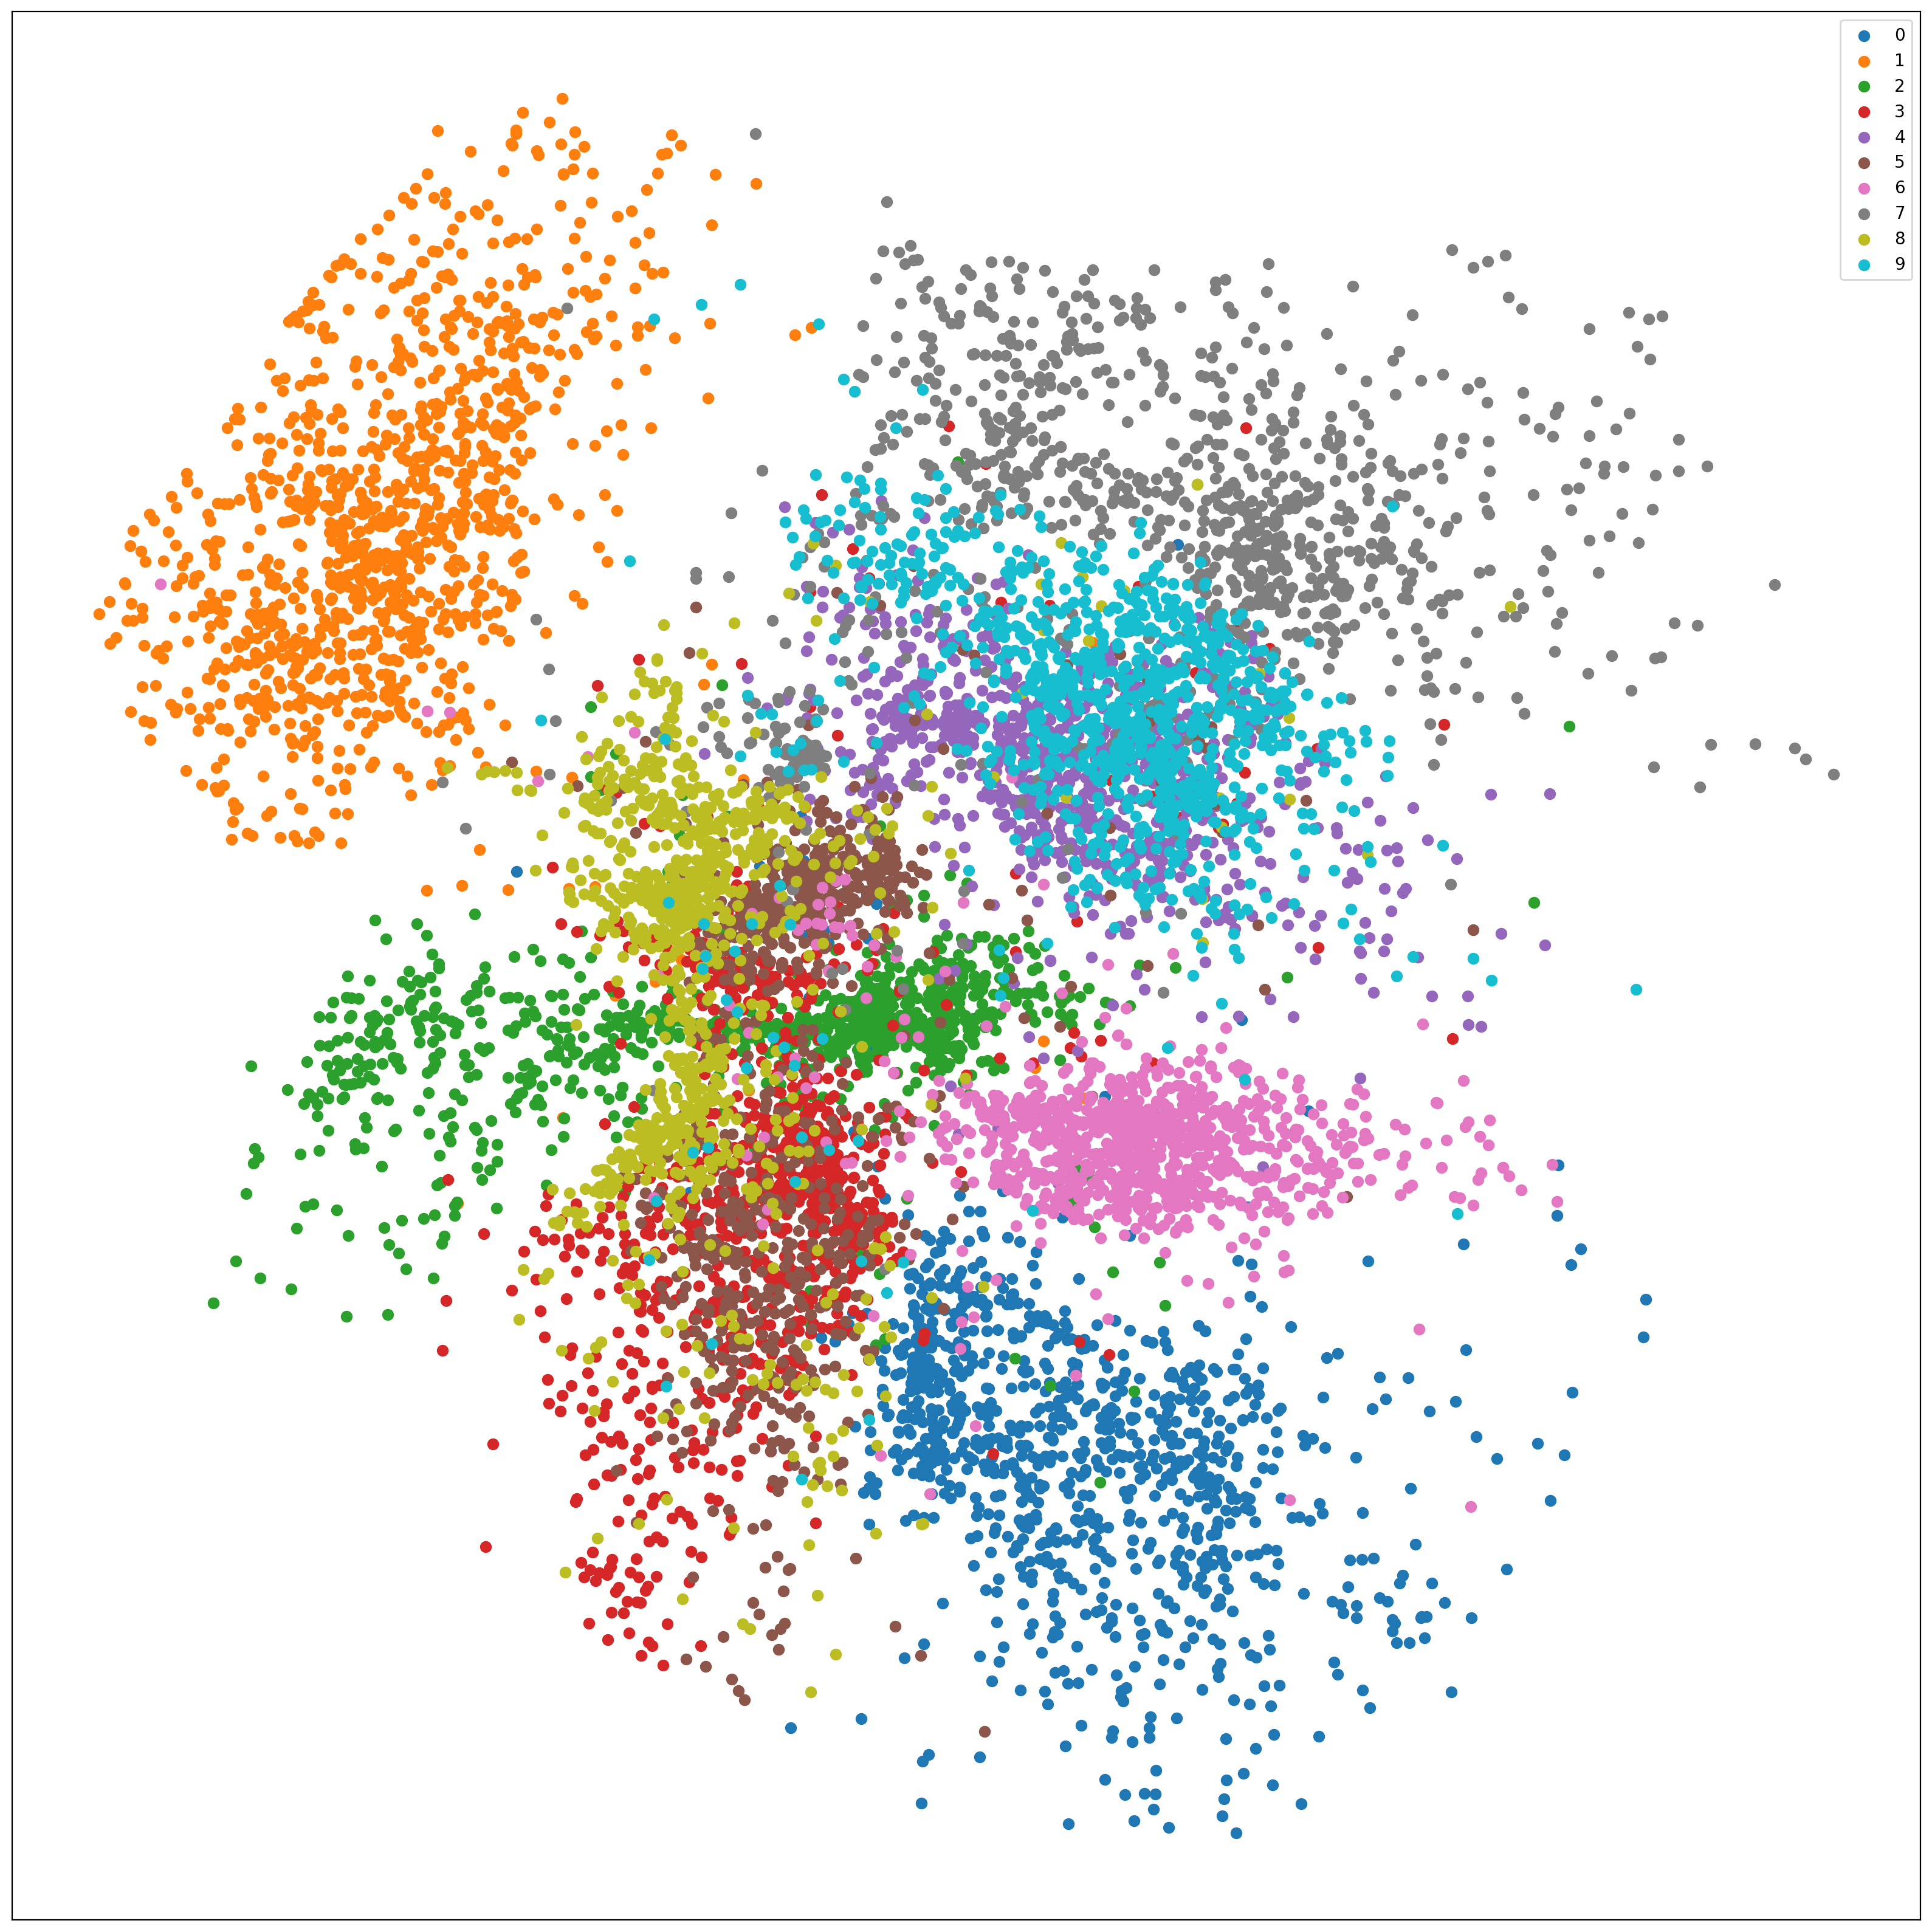

In [31]:
dbn = [
    RestrictedBoltzmannMachine(
        VISIBLE_LAYER_SIZE, 256, sigmoid, sigmoid, RBM_LEARNING_RATE, 0.5, L2_PENALTY
    ),
    RestrictedBoltzmannMachine(
        256, 128, sigmoid, sigmoid, RBM_LEARNING_RATE, 0.5, L2_PENALTY
    ),
    RestrictedBoltzmannMachine(
        128, 64, sigmoid, sigmoid, RBM_LEARNING_RATE, 0.5, L2_PENALTY
    ),
    RestrictedBoltzmannMachine(
        64, 2, sigmoid, gaussian, RBM_LEARNING_RATE / 10.0, 0.5, L2_PENALTY
    ),
]

ae: MLP = [
    # encoder
    Layer(
        VISIBLE_LAYER_SIZE,
        256,
        sigmoid,
        sigmoid_derivative,
        AE_LEARNING_RATE,
        AE_MOMENTUM,
        L2_PENALTY,
    ),
    Layer(
        256, 128, sigmoid, sigmoid_derivative, AE_LEARNING_RATE, AE_MOMENTUM, L2_PENALTY
    ),
    Layer(
        128, 64, sigmoid, sigmoid_derivative, AE_LEARNING_RATE, AE_MOMENTUM, L2_PENALTY
    ),
    Layer(
        64,
        2,
        gaussian,
        gaussian_derivative,
        AE_LEARNING_RATE / 10.0,
        AE_MOMENTUM,
        L2_PENALTY,
    ),
    # decoder (mirrored)
    Layer(
        2,
        64,
        sigmoid,
        sigmoid_derivative,
        AE_LEARNING_RATE / 10.0,
        AE_MOMENTUM,
        L2_PENALTY,
    ),
    Layer(
        64, 128, sigmoid, sigmoid_derivative, AE_LEARNING_RATE, AE_MOMENTUM, L2_PENALTY
    ),
    Layer(
        128, 256, sigmoid, sigmoid_derivative, AE_LEARNING_RATE, AE_MOMENTUM, L2_PENALTY
    ),
    Layer(
        256,
        VISIBLE_LAYER_SIZE,
        sigmoid,
        sigmoid_derivative,
        AE_LEARNING_RATE,
        AE_MOMENTUM,
        L2_PENALTY,
    ),
]

compare_2d_visualizations(
    ae,
    dbn,
    mnist_train_images,
    mnist_test_images,
    mnist_test_labels,
    monitoring_set,
    BATCH_SIZE,
    EPOCHS_COUNT,
)